# Exploración Climática de Ciudades del Perú

Datos diarios de temperatura y precipitación (2023) via Open-Meteo API

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

PALETA = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#606C38']
sns.set_palette(PALETA)

## Extracción de datos desde Open-Meteo

In [2]:
ciudades = {
    "Lima": (-12.05, -77.04),
    "Arequipa": (-16.40, -71.54),
    "Cusco": (-13.52, -71.97),
    "Iquitos": (-3.75, -73.25),
    "Puno": (-15.84, -70.02),
    "Piura": (-5.19, -80.63),
}

frames = []
for ciudad, (lat, lon) in ciudades.items():
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": "2023-01-01", "end_date": "2023-12-31",
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
        "timezone": "America/Lima"
    }
    resp = requests.get(url, params=params, timeout=30)
    data = resp.json()["daily"]
    df = pd.DataFrame(data)
    df["ciudad"] = ciudad
    frames.append(df)

clima = pd.concat(frames, ignore_index=True)
clima["time"] = pd.to_datetime(clima["time"])
clima["amplitud_termica"] = clima["temperature_2m_max"] - clima["temperature_2m_min"]
clima["mes"] = clima["time"].dt.month
clima.shape

(2190, 7)

In [3]:
clima.head(10)

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,ciudad,amplitud_termica,mes
0,2023-01-01,23.0,18.8,0.0,Lima,4.2,1
1,2023-01-02,23.8,18.1,0.2,Lima,5.7,1
2,2023-01-03,22.9,18.7,2.2,Lima,4.2,1
3,2023-01-04,22.2,18.8,0.0,Lima,3.4,1
4,2023-01-05,24.2,18.2,0.0,Lima,6.0,1
5,2023-01-06,22.3,17.9,0.0,Lima,4.4,1
6,2023-01-07,22.4,17.6,0.0,Lima,4.8,1
7,2023-01-08,22.0,17.5,0.0,Lima,4.5,1
8,2023-01-09,22.8,17.7,0.0,Lima,5.1,1
9,2023-01-10,22.7,19.0,0.6,Lima,3.7,1


In [4]:
clima.groupby('ciudad')[['temperature_2m_max', 'temperature_2m_min', 'precipitation_sum']].describe().round(1)

temperature_2m_max                                           \
                      count  mean  std   min   25%   50%   75%   max   
ciudad                                                                 
Arequipa              365.0  22.5  2.2  16.8  21.4  23.0  24.1  26.3   
Cusco                 365.0  17.7  1.9  11.8  16.5  17.6  19.0  22.9   
Iquitos               365.0  30.5  2.3  21.8  28.7  30.5  32.2  36.7   
Lima                  365.0  22.9  2.0  19.2  21.3  22.3  24.2  28.0   
Piura                 365.0  32.5  1.7  25.7  31.4  32.2  33.2  37.4   
Puno                  365.0  15.5  2.1   9.7  14.0  15.4  16.8  22.6   

         temperature_2m_min        ...             precipitation_sum       \
                      count  mean  ...   75%   max             count mean   
ciudad                             ...                                      
Arequipa              365.0   9.9  ...  11.0  14.6             365.0  1.1   
Cusco                 365.0   6.5  ...   7.8  10.4             365.0  3.4   
Iquitos               365.0  23.6  ...  24.3  26.2             365.0  7.9   
Lima                  365.0  18.4  ...  20.1  22.8             365.0  0.2   
Piura                 365.0  21.3  ...  22.4  24.6             365.0  2.2   
Puno                  365.0   4.2  ...   5.8   9.0             365.0  2.9   

                                          
          std  min  25%  50%   75%   max  
ciudad                                    
Arequipa  3.6  0.0  0.0  0.0   0.0  29.6  
Cusco     4.6  0.0  0.1  1.5   4.9  31.7  
Iquitos   8.5  0.0  1.1  4.5  12.6  48.2  
Lima      0.7  0.0  0.0  0.0   0.0   6.6  
Piura     6.5  0.0  0.0  0.0   0.4  61.1  
Puno      4.5  0.0  0.0  0.5   4.2  23.3  

[6 rows x 24 columns]

## Temperatura máxima promedio mensual por ciudad

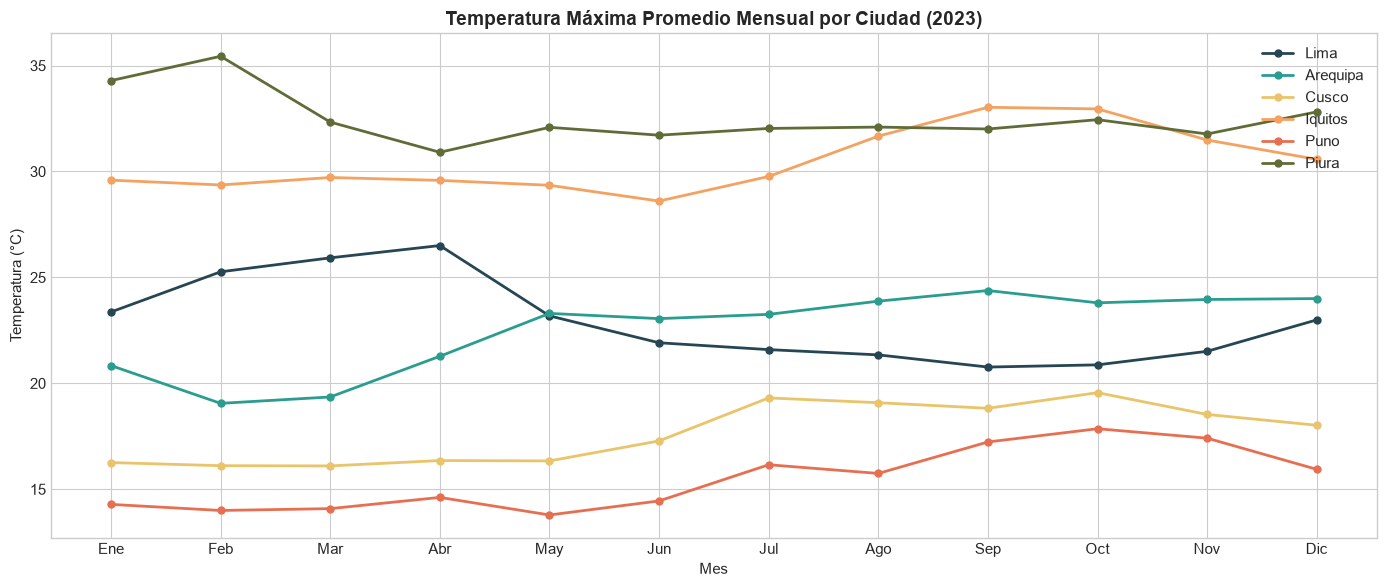

In [5]:
mensual_temp = clima.groupby(['ciudad', 'mes'])['temperature_2m_max'].mean().reset_index()
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, ax = plt.subplots(figsize=(14, 6))
for i, ciudad in enumerate(ciudades.keys()):
    datos = mensual_temp[mensual_temp['ciudad'] == ciudad]
    ax.plot(datos['mes'], datos['temperature_2m_max'], marker='o', markersize=5,
            label=ciudad, color=PALETA[i], linewidth=2)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_labels)
ax.set_title('Temperatura Máxima Promedio Mensual por Ciudad (2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Temperatura (°C)')
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

## Distribución de temperatura máxima por ciudad

/var/folders/tl/wg__gcjn297fhnfclpjmjygc0000gn/T/ipykernel_85321/4086770419.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=clima, x='ciudad', y='temperature_2m_max', order=orden_ciudades,


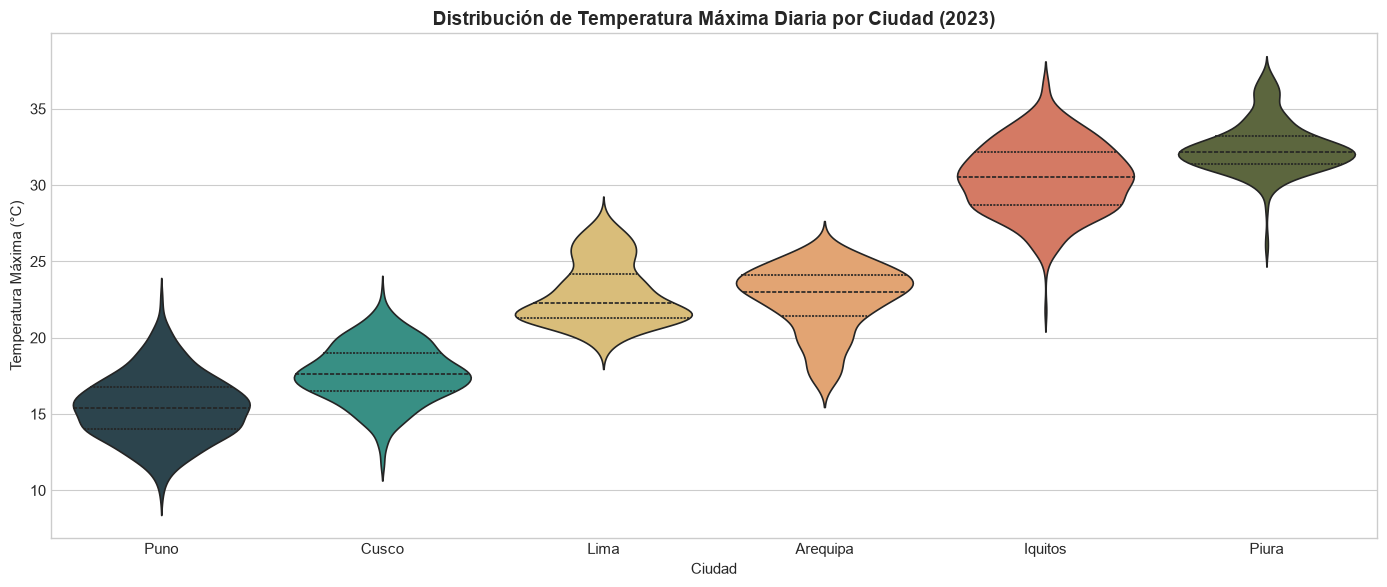

In [6]:
orden_ciudades = clima.groupby('ciudad')['temperature_2m_max'].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=clima, x='ciudad', y='temperature_2m_max', order=orden_ciudades,
               palette=PALETA, inner='quartile', ax=ax, linewidth=1.2)
ax.set_title('Distribución de Temperatura Máxima Diaria por Ciudad (2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ciudad')
ax.set_ylabel('Temperatura Máxima (°C)')
plt.tight_layout()
plt.show()

## Precipitación mensual: Lima vs Iquitos vs Cusco

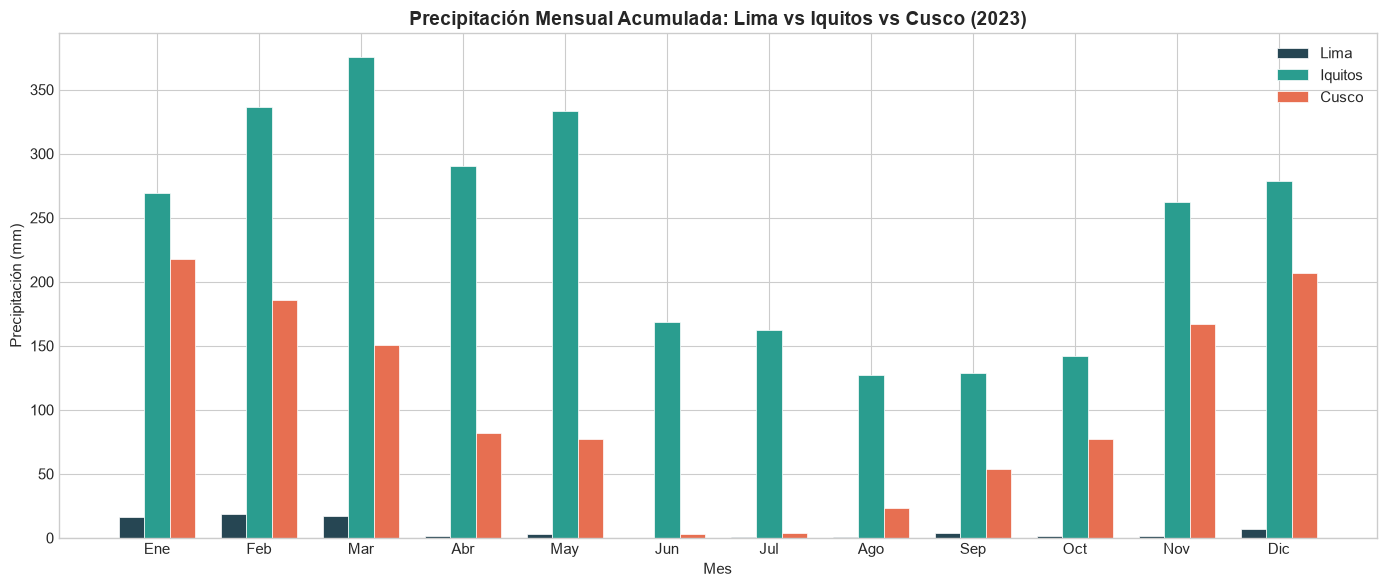

In [7]:
ciudades_precip = ['Lima', 'Iquitos', 'Cusco']
precip_mensual = (clima[clima['ciudad'].isin(ciudades_precip)]
                  .groupby(['ciudad', 'mes'])['precipitation_sum']
                  .sum().reset_index())

colores_precip = {'Lima': '#264653', 'Iquitos': '#2A9D8F', 'Cusco': '#E76F51'}
x = np.arange(12)
ancho = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, ciudad in enumerate(ciudades_precip):
    datos = precip_mensual[precip_mensual['ciudad'] == ciudad].sort_values('mes')
    ax.bar(x + i * ancho, datos['precipitation_sum'].values, ancho,
           label=ciudad, color=colores_precip[ciudad], edgecolor='white', linewidth=0.5)

ax.set_xticks(x + ancho)
ax.set_xticklabels(meses_labels)
ax.set_title('Precipitación Mensual Acumulada: Lima vs Iquitos vs Cusco (2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Precipitación (mm)')
ax.legend()
plt.tight_layout()
plt.show()

## Temperatura diaria por ciudad (interactivo)

In [8]:
fig = px.line(clima, x='time', y='temperature_2m_max', color='ciudad',
              title='Temperatura Máxima Diaria por Ciudad (2023)',
              labels={'temperature_2m_max': 'Temp. Máxima (°C)', 'time': 'Fecha', 'ciudad': 'Ciudad'},
              color_discrete_sequence=PALETA,
              template='plotly_white')
fig.update_layout(
    hovermode='x unified',
    legend=dict(orientation='h', y=-0.15),
    xaxis=dict(rangeslider=dict(visible=True), type='date')
)
fig.update_traces(line=dict(width=1.2))
fig.show()

## Temperatura promedio mensual por ciudad (heatmap interactivo)

In [9]:
pivot_temp = clima.groupby(['ciudad', 'mes'])['temperature_2m_max'].mean().reset_index()
pivot_wide = pivot_temp.pivot(index='ciudad', columns='mes', values='temperature_2m_max')
pivot_wide.columns = meses_labels

fig = px.imshow(pivot_wide.round(1),
                title='Temperatura Máxima Promedio Mensual por Ciudad',
                labels=dict(x='Mes', y='Ciudad', color='Temp. (°C)'),
                color_continuous_scale='YlOrRd',
                text_auto='.1f',
                template='plotly_white',
                aspect='auto')
fig.update_layout(height=400)
fig.show()

## Resumen por ciudad

In [10]:
resumen = clima.groupby('ciudad').agg(
    temp_max_media=('temperature_2m_max', 'mean'),
    temp_min_media=('temperature_2m_min', 'mean'),
    amplitud_media=('amplitud_termica', 'mean'),
    precip_total=('precipitation_sum', 'sum'),
    dias_con_lluvia=('precipitation_sum', lambda x: (x > 0.1).sum()),
    registros=('time', 'count')
).round(1)
resumen.sort_values('temp_max_media', ascending=False)

,temp_max_media,temp_min_media,amplitud_media,precip_total,dias_con_lluvia,registros
ciudad,,,,,,
Piura,32.5,21.3,11.2,787.8,102,365
Iquitos,30.5,23.6,6.9,2874.7,338,365
Lima,22.9,18.4,4.6,71.8,62,365
Arequipa,22.5,9.9,12.7,418.0,77,365
Cusco,17.7,6.5,11.2,1249.0,272,365
Puno,15.5,4.2,11.3,1040.7,219,365
